<a href="https://colab.research.google.com/github/subham-28/ML/blob/main/startup_success%20predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving final.csv to final.csv


In [2]:
import numpy as np
import pandas as pd


df = pd.read_csv("final.csv")

In [3]:
df.head(5)

,Company's Name,Risk Tolerant Score (1-10),Resilience Score (1-10),Decision Making Speed (hrs),Adaptability (1-10),No of hrs per month spend with mentor,Funding Secured,Prev Entrepreneurial Experience (yes/no),Education,Networking Level (low/med/high),Sustainability (yes/no),Success
0,Meesho Superstore,7,6,24,7,10,Yes,No,"B.Tech (Electrical Engg., IIT Delhi)",Med,No,Yes
1,Flipkart,9,8,12,9,20,Yes,Yes,MBA (IIT Delhi + ISB),High,Yes,Yes
2,Doodhwala,6,5,48,5,5,Yes,No,NaN,Low,No,No
3,Nykaa,8,7,18,8,15,Yes,Yes,MBA (IIM Ahmedabad),High,Yes,Yes
4,Koinex,9,4,72,6,8,No,No,B.Tech (IIT Bombay),Med,No,No


In [4]:
df.shape

(100, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Company's Name                            100 non-null    object
 1   Risk Tolerant Score (1-10)                100 non-null    int64 
 2   Resilience Score (1-10)                   100 non-null    int64 
 3   Decision Making Speed (hrs)               100 non-null    int64 
 4   Adaptability (1-10)                       100 non-null    int64 
 5   No of hrs per month spend with mentor     100 non-null    int64 
 6   Funding Secured                           100 non-null    object
 7   Prev Entrepreneurial Experience (yes/no)  100 non-null    object
 8   Education                                 86 non-null     object
 9   Networking Level (low/med/high)           100 non-null    object
 10  Sustainability (yes/no)                   100 non-n

In [6]:
df.describe()

,Risk Tolerant Score (1-10),Resilience Score (1-10),Decision Making Speed (hrs),Adaptability (1-10),No of hrs per month spend with mentor
count,100.000000,100.0000,100.000000,100.000000,100.000000
mean,7.140000,6.5400,26.520000,7.500000,11.950000
std,1.180823,2.0222,12.538812,1.193416,4.351651
min,5.000000,1.0000,12.000000,5.000000,5.000000
25%,6.000000,5.0000,18.000000,7.000000,8.000000
50%,7.000000,7.0000,24.000000,8.000000,10.000000
75%,8.000000,8.0000,36.000000,9.000000,15.000000
max,9.000000,9.0000,72.000000,9.000000,20.000000


In [7]:
df['Education'] = df['Education'].fillna('Others')
df['Education'] = df['Education'].replace('', 'Others')

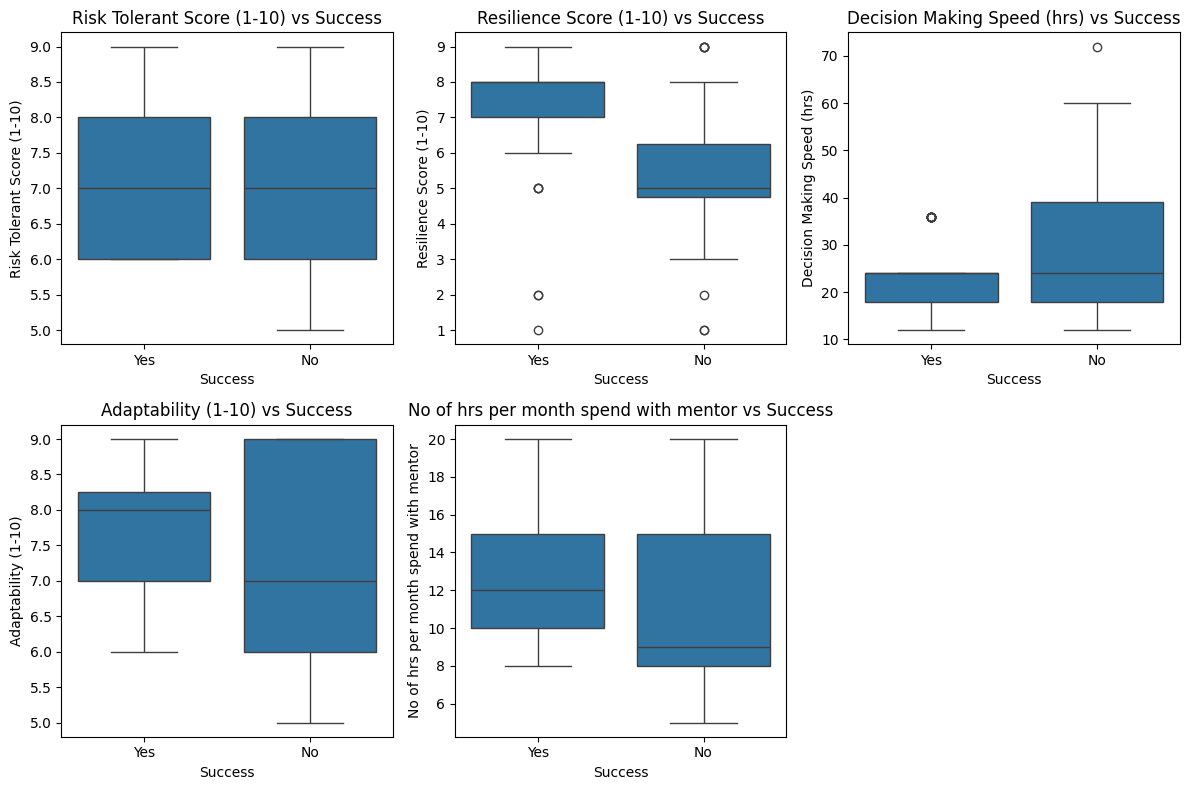

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 8))
numeric_cols = ['Risk Tolerant Score (1-10)', 'Resilience Score (1-10)',
                'Decision Making Speed (hrs)', 'Adaptability (1-10)',
                'No of hrs per month spend with mentor']

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Success', y=col, data=df)
    plt.title(f'{col} vs Success')
plt.tight_layout()
plt.show()

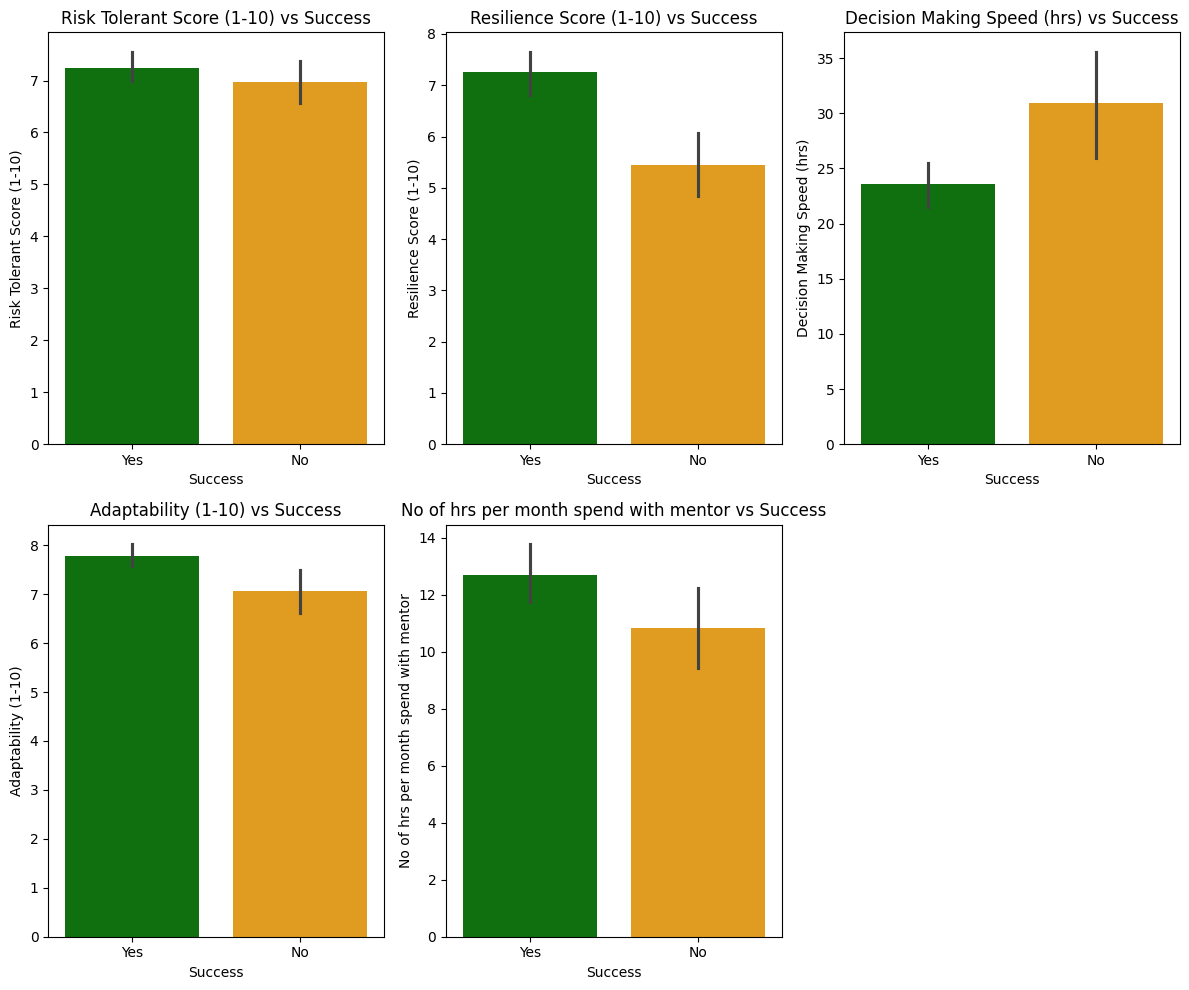

In [9]:
plt.figure(figsize=(12, 10))
numeric_cols = ['Risk Tolerant Score (1-10)', 'Resilience Score (1-10)',
                'Decision Making Speed (hrs)', 'Adaptability (1-10)',
                'No of hrs per month spend with mentor']


custom_palette = {"Yes": "Green", "No": "Orange"}

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x='Success', y=col, data=df,hue='Success', palette=custom_palette,
                order=["Yes", "No"])
    plt.title(f'{col} vs Success')
plt.tight_layout()
plt.show()

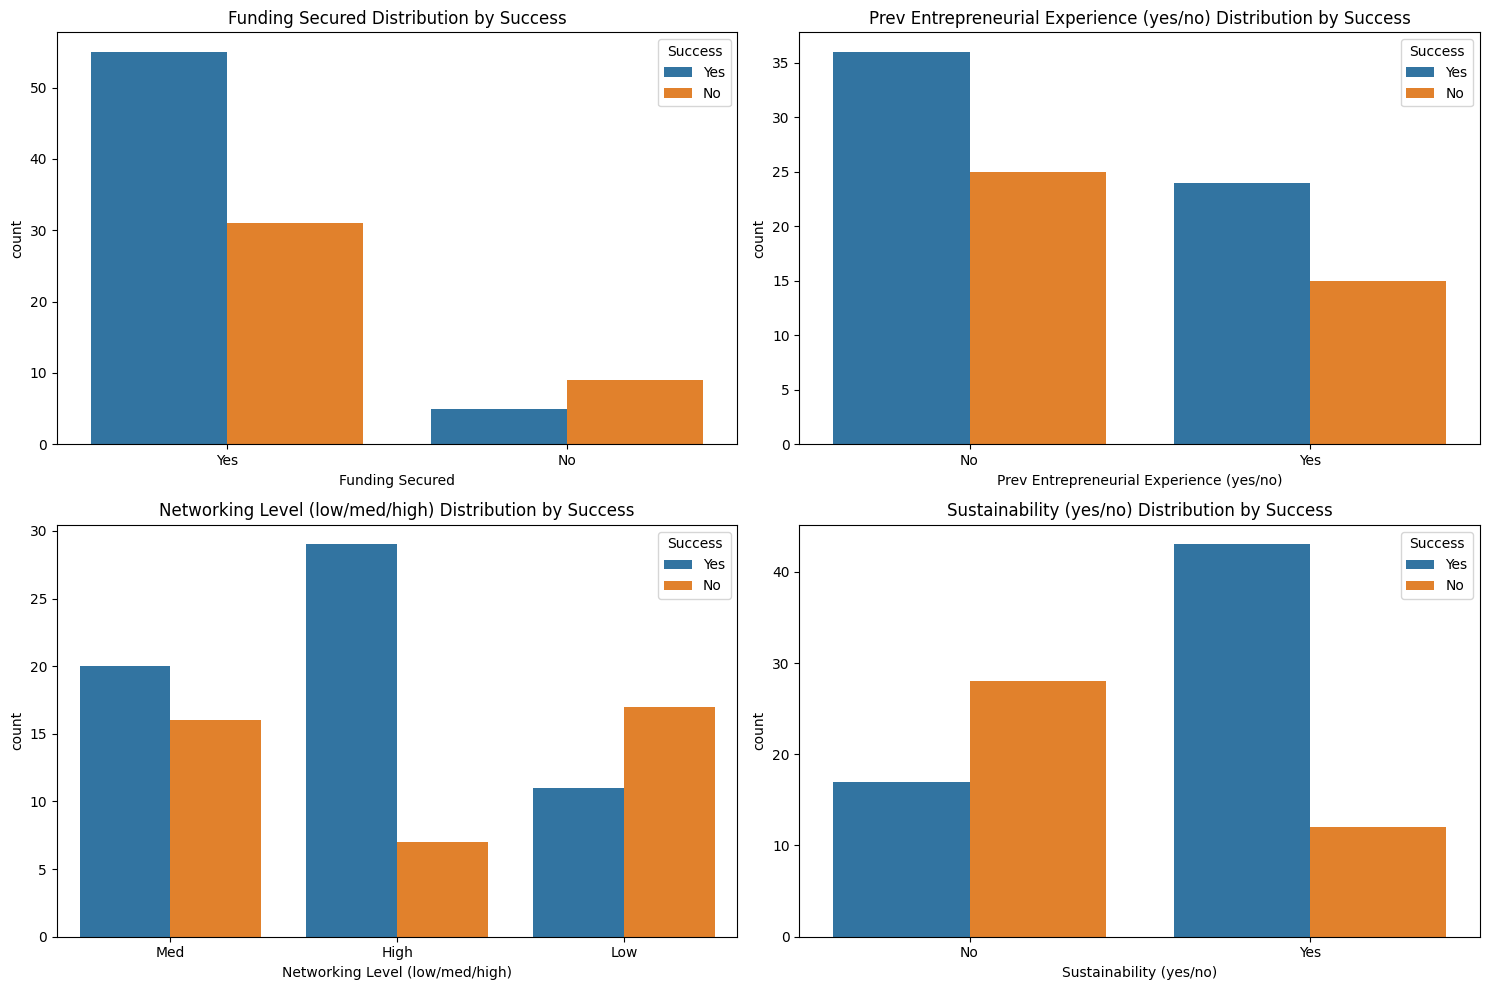

In [10]:
cat_cols = ['Funding Secured', 'Prev Entrepreneurial Experience (yes/no)',
            'Networking Level (low/med/high)', 'Sustainability (yes/no)']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='Success', data=df)
    plt.title(f'{col} Distribution by Success')
plt.tight_layout()
plt.show()

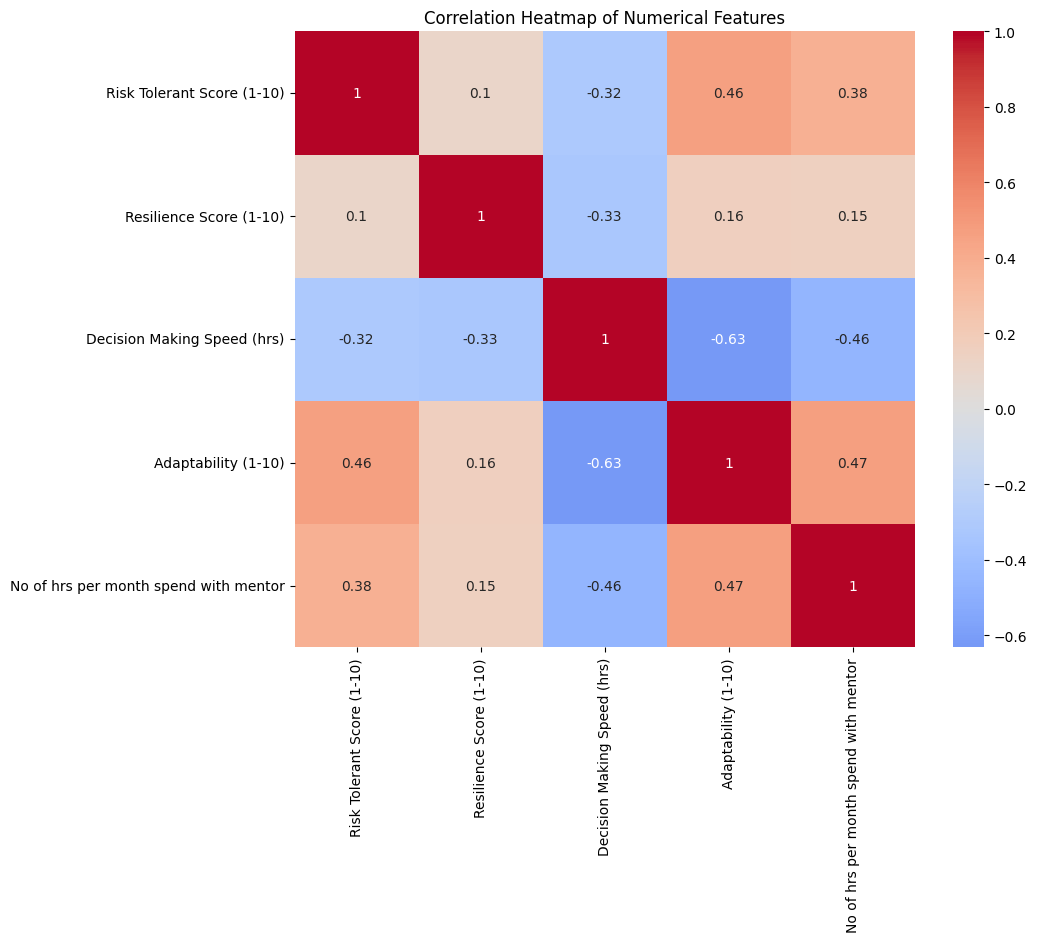

In [11]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

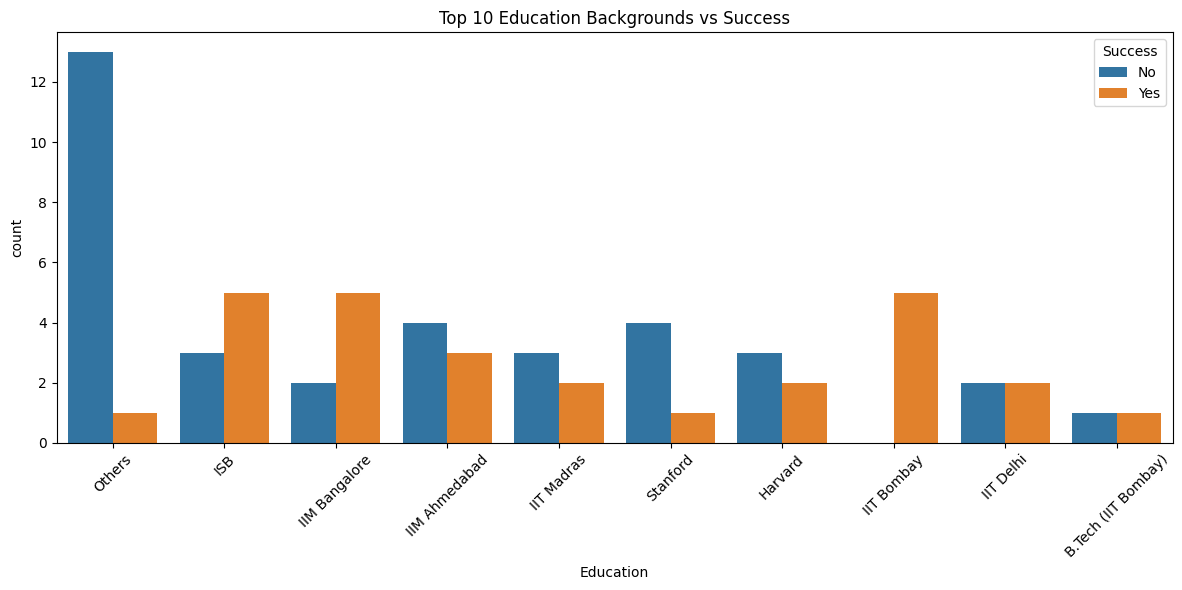

In [12]:
top_edu = df['Education'].value_counts().head(10).index
edu_success = df[df['Education'].isin(top_edu)]
plt.figure(figsize=(12, 6))
sns.countplot(x='Education', hue='Success', data=edu_success, order=top_edu)
plt.title('Top 10 Education Backgrounds vs Success')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

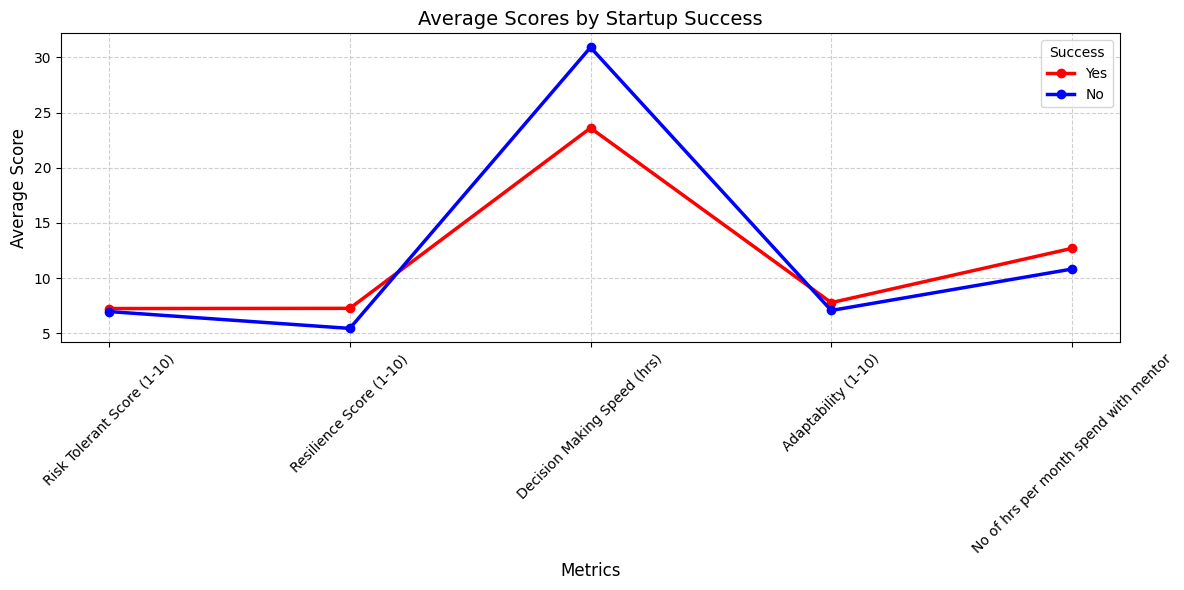

In [13]:
numeric_cols = ['Risk Tolerant Score (1-10)', 'Resilience Score (1-10)',
                'Decision Making Speed (hrs)', 'Adaptability (1-10)',
                'No of hrs per month spend with mentor']
success_order = ["Yes", "No"]
custom_palette = {"Yes": "Red", "No": "Blue"}

mean_df = df.groupby('Success')[numeric_cols].mean().loc[success_order]

plt.figure(figsize=(12, 6))
for success in success_order:
    plt.plot(mean_df.columns,
             mean_df.loc[success],
             marker='o',
             label=success,
             color=custom_palette[success],
             linewidth=2.5)

plt.title('Average Scores by Startup Success', fontsize=14)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Success')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [14]:
df['Success'] = df['Success'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Sustainability (yes/no)'] = df['Sustainability (yes/no)'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Funding Secured'] = df['Funding Secured'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Prev Entrepreneurial Experience (yes/no)'] = df['Prev Entrepreneurial Experience (yes/no)'].apply(lambda x: 1 if x == 'Yes' else 0)


In [15]:
df.sample(5)

,Company's Name,Risk Tolerant Score (1-10),Resilience Score (1-10),Decision Making Speed (hrs),Adaptability (1-10),No of hrs per month spend with mentor,Funding Secured,Prev Entrepreneurial Experience (yes/no),Education,Networking Level (low/med/high),Sustainability (yes/no),Success
88,Koo App,9,5,24,9,15,1,0,IIM Ahmedabad,Med,0,0
7,CRED,8,9,12,9,18,1,1,BA Philosophy (Wilson College),High,0,1
93,CardBack,7,5,24,9,20,1,1,ISB,Med,1,0
62,Licious,7,9,36,9,20,1,0,IIT Bombay,High,1,1
20,Anar,6,5,48,6,6,1,0,Others,Med,0,0


In [16]:
df.drop("Company's Name",axis=1,inplace=True)
df.drop("Education",axis=1,inplace=True)

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Success',axis=1),df['Success'],test_size=0.2,random_state=42)

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

transformer=ColumnTransformer(transformers=[
    ('tnf1',OrdinalEncoder(categories=[['Low','Med','High']]),['Networking Level (low/med/high)'])
],remainder='passthrough')
x_train_trans=transformer.fit_transform(x_train)
x_test_trans=transformer.transform(x_test)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,roc_curve, roc_auc_score, confusion_matrix, classification_report

log_reg = LogisticRegression(solver='liblinear', penalty='l2', C=10)
log_reg.fit(x_train_trans, y_train)

y_pred = log_reg.predict(x_test_trans)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of Logistic Regression: {accuracy * 100:.2f}%')

Accuracy of Logistic Regression: 75.00%


In [24]:
y_pred_proba = log_reg.predict_proba(x_test_trans)[:, 1]
print("Regression Coefficients:")

feature_names = transformer.get_feature_names_out()

for feature, coef in zip(feature_names, log_reg.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}\n")

Regression Coefficients:
tnf1__Networking Level (low/med/high): 1.1908
remainder__Risk Tolerant Score (1-10): -0.1760
remainder__Resilience Score (1-10): -0.0586
remainder__Decision Making Speed (hrs): -0.0688
remainder__Adaptability (1-10): 0.3459
remainder__No of hrs per month spend with mentor: 0.0151
remainder__Funding Secured: 1.2785
remainder__Prev Entrepreneurial Experience (yes/no): -1.8850
remainder__Sustainability (yes/no): 2.0732

Intercept: -1.5365



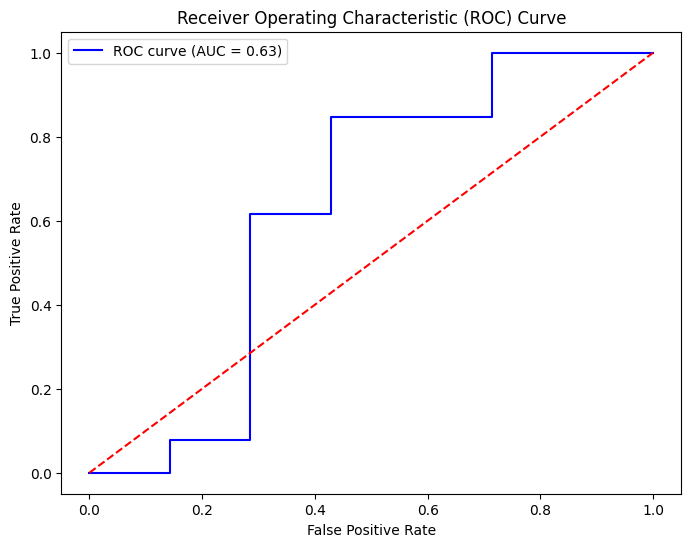

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [26]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 4  3]
 [ 2 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.57      0.62         7
           1       0.79      0.85      0.81        13

    accuracy                           0.75        20
   macro avg       0.73      0.71      0.72        20
weighted avg       0.74      0.75      0.75        20

